# Problem statement

In [53]:
# Biz bu data set orqali 1 galoon(taxminan 3.7 litr)ga qancha masofani bosib otishini taxmin qilamiz

# Used words in this dataset

In [9]:
# model	  ------   Avtomobilning aniq nomi yoki modeli.

# model_index	----------   Modelning indeks yoki kod raqami (ma’lumotlar bazasida identifikatsiya uchun).

# displacement	--------    Dvigatel hajmi (odatda litr yoki kub santimetrda, masalan 2.0L).

# cylinders	---------    Dvigateldagi silindrlar soni (4, 6, 8 va hokazo).

# gears	---------    Uzatmalar qutisidagi tezliklar soni (masalan, 5 pog‘onali).

# transmission	-------   Uzatmalar qutisi turi (manual — qo‘lda, automatic — avtomat).

# mpg	--------    “Miles per gallon” — yonilg‘i tejamkorligi (1 gallon yonilg‘ida necha mil yuradi).

# aspiration	--------   Havo kirish turi: tabiiy (NA — naturally aspirated) yoki majburiy (turbo/supercharger).

# lockup_torque_converter	--------  Avtomatik transmissiyada “lock-up” funksiyali moment o‘zgartirgich mavjudligi.

# drive   ------– Harakat tizimi: old g‘ildirak (FWD), orqa g‘ildirak (RWD), to‘liq (AWD/4WD)

# max_ethanol   ---------    Yonilg‘idagi maksimal etanol foizi (masalan, E10 — 10% etanol).

# recommended_fuel	--------   Ishlab chiqaruvchi tavsiya qilgan yonilg‘i turi (Regular, Premium va hokazo).

# intake_valves_per_cyl	--------    Har bir silindrga to‘g‘ri keladigan kirish (havo/yonilg‘i) klapanlari soni.

# exhaust_valves_per_cyl	--------   Har bir silindrga to‘g‘ri keladigan chiqish (gaz) klapanlari soni.

# fuel_injection   ---------    Yonilg‘i purkash tizimi turi (port injection, direct injection va boshqalar).

# Kutubxonalarni chaqirish

In [59]:
import pandas as pd
import numpy as np

from joblib import dump
import os

import matplotlib.pyplot as plt
import seaborn as sns
import klib

from sklearn.model_selection import train_test_split, KFold,cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler

minmax = MinMaxScaler()
labeller = LabelEncoder()

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression

DT_Reg = DecisionTreeRegressor()
RF_Reg = RandomForestRegressor()
svr = SVR()
LR_Reg = LinearRegression()

from sklearn.metrics import r2_score,mean_absolute_error

# Datani chaqirish

In [104]:
df = pd.read_csv(r"C:\Users\bunyo\Downloads\Telegram Desktop\cars2018.csv")

# Dataset bilan tanishamiz

In [12]:
df.sample(3)

,model,model_index,displacement,cylinders,gears,transmission,mpg,aspiration,lockup_torque_converter,drive,max_ethanol,recommended_fuel,intake_valves_per_cyl,exhaust_valves_per_cyl,fuel_injection
89,Porsche 911 Carrera 4,109,3.0,6,7,Manual,23,Turbocharged/Supercharged,N,4-Wheel Drive,10,Premium Unleaded Required,2,2,Direct ignition
1090,Ford EXPLORER AWD,137,3.5,6,6,Automatic,18,Turbocharged/Supercharged,Y,All Wheel Drive,15,Regular Unleaded Recommended,2,2,Direct ignition
312,KIA MOTORS CORPORATION Rio,28,1.6,4,6,Automatic,32,Naturally Aspirated,Y,"2-Wheel Drive, Front",15,Regular Unleaded Recommended,2,2,Direct ignition


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1144 entries, 0 to 1143
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   model                    1144 non-null   object 
 1   model_index              1144 non-null   int64  
 2   displacement             1144 non-null   float64
 3   cylinders                1144 non-null   int64  
 4   gears                    1144 non-null   int64  
 5   transmission             1144 non-null   object 
 6   mpg                      1144 non-null   int64  
 7   aspiration               1144 non-null   object 
 8   lockup_torque_converter  1144 non-null   object 
 9   drive                    1144 non-null   object 
 10  max_ethanol              1144 non-null   int64  
 11  recommended_fuel         1144 non-null   object 
 12  intake_valves_per_cyl    1144 non-null   int64  
 13  exhaust_valves_per_cyl   1144 non-null   int64  
 14  fuel_injection          

In [14]:
df.nunique()

model                      750
model_index                456
displacement                41
cylinders                    8
gears                        8
transmission                 3
mpg                         38
aspiration                   2
lockup_torque_converter      2
drive                        4
max_ethanol                  3
recommended_fuel             3
intake_valves_per_cyl        2
exhaust_valves_per_cyl       2
fuel_injection               2
dtype: int64

# Keraksiz ustunnni tashab yuboramiz masalan -> Model Index

In [105]:
df.drop(columns=['model_index'],inplace=True)

# Class yaratamiz

In [106]:
class Preprocessing:
    def __init__(self,df):
        self.df=df
        
# Encoding qiluvchi
    def encoding_qilish(self):
        for col in self.df.columns:
            if self.df[col].dtype == 'object':
                if self.df[col].nunique() <= 2:
                    new_df = pd.get_dummies(self.df[col], prefix='New', dtype=int)
                    self.df.drop(columns=[col],inplace=True)
                    self.df = pd.concat([self.df,new_df],axis=1)
                else:
                    self.df[col] = labeller.fit_transform(self.df[col])
        return self
    
# Scale qiluvchi
    def scaling_qilish(self):
        for cols in self.df.columns:
            if self.df[cols].dtype != 'object' and self.df[cols].name != 'mpg':
                self.df[cols] = minmax.fit_transform(self.df[[cols]])
        return self
    
# To'ldruvchi
    def fillingNan(self):
        for cols in self.df.columns:
            if self.df[cols].isnull().any():
                if self.df[cols].dtype == 'object':
                    self.df[cols].fillna(self.df[cols].mode()[0], inplace=True)
                else:
                    self.df[cols].fillna(self.df[cols].mean(),inplace=True)
        return self          

# class orqali datani preprocess qilamiz

In [107]:
data_preprosesing = Preprocessing(df)
data_preprosesing.fillingNan().encoding_qilish().scaling_qilish()
preprocessed_data = data_preprosesing.df

In [108]:
preprocessed_data

,model,displacement,cylinders,gears,transmission,mpg,drive,max_ethanol,recommended_fuel,intake_valves_per_cyl,exhaust_valves_per_cyl,New_Naturally Aspirated,New_Turbocharged/Supercharged,New_N,New_Y,New_Direct ignition,New_Multipoint/sequential ignition
0,0.009346,0.357143,0.230769,0.888889,1.0,21,1.000000,0.000000,0.5,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0
1,0.000000,0.114286,0.076923,0.555556,1.0,28,0.333333,0.000000,0.5,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0
2,0.045394,0.600000,0.538462,0.666667,1.0,17,1.000000,0.066667,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0
3,0.046729,0.600000,0.538462,0.666667,1.0,18,0.333333,0.066667,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0
4,0.048064,0.600000,0.538462,0.666667,1.0,17,1.000000,0.066667,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1139,0.927904,0.671429,0.384615,0.777778,0.0,15,0.666667,0.066667,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0
1140,0.941255,0.671429,0.384615,0.555556,0.0,14,0.666667,0.066667,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0
1141,0.942590,0.671429,0.384615,0.555556,0.0,14,0.666667,1.000000,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0
1142,0.998665,0.142857,0.076923,0.777778,0.0,24,1.000000,0.000000,0.5,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0


# preprossed datani saqlab qoyamiz

In [111]:
import os

folder_name = 'Final_Project/data/preprocessed'
os.makedirs(folder_name, exist_ok=True)
out_path = os.path.join(folder_name, 'preprossed_df.csv')
preprocessed_data.to_csv(out_path,index=False)

# target qiymatga(mpg) juda kam korelatsya bo'gan ustunni tashlab yuboramiz -> Fuel Injection qiymatini

In [19]:
corr_df = preprocessed_data.corr()['mpg']
print(corr_df)

model                                 0.119912
displacement                         -0.740938
cylinders                            -0.713924
gears                                -0.385157
transmission                          0.244639
mpg                                   1.000000
drive                                -0.373795
max_ethanol                          -0.124257
recommended_fuel                      0.152029
intake_valves_per_cyl                 0.277959
exhaust_valves_per_cyl                0.291316
New_Naturally Aspirated               0.007729
New_Turbocharged/Supercharged        -0.007729
New_N                                 0.247939
New_Y                                -0.247939
New_Direct ignition                  -0.019907
New_Multipoint/sequential ignition    0.019907
Name: mpg, dtype: float64


In [20]:
preprocessed_data.drop(columns=['New_Direct ignition','max_ethanol','New_Multipoint/sequential ignition','New_Turbocharged/Supercharged','New_Naturally Aspirated'],inplace=True)

In [21]:
preprocessed_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1144 entries, 0 to 1143
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   model                   1144 non-null   float64
 1   displacement            1144 non-null   float64
 2   cylinders               1144 non-null   float64
 3   gears                   1144 non-null   float64
 4   transmission            1144 non-null   float64
 5   mpg                     1144 non-null   int64  
 6   drive                   1144 non-null   float64
 7   recommended_fuel        1144 non-null   float64
 8   intake_valves_per_cyl   1144 non-null   float64
 9   exhaust_valves_per_cyl  1144 non-null   float64
 10  New_N                   1144 non-null   float64
 11  New_Y                   1144 non-null   float64
dtypes: float64(11), int64(1)
memory usage: 107.4 KB


# data ni ajratamiz

In [22]:
x = preprocessed_data.drop('mpg',axis=1)
y = preprocessed_data['mpg']

# skewness bilan ishlaymiz

In [23]:
skew = x.skew()

In [26]:
skew

model                     0.134643
displacement              0.928599
cylinders                 1.227052
gears                    -1.180891
transmission              0.878729
drive                     0.159967
recommended_fuel         -0.496366
intake_valves_per_cyl    -3.250660
exhaust_valves_per_cyl   -3.156646
New_N                     1.382734
New_Y                    -1.382734
dtype: float64

# Filter

In [ ]:
Log_transform = skew[skew >=0.7].index.to_list()
Pow_transform = skew[skew < 0].index.to_list()

print(Log_transform)
print(Pow_transform)

['displacement', 'cylinders', 'transmission', 'New_N']
['gears', 'recommended_fuel', 'intake_valves_per_cyl', 'exhaust_valves_per_cyl', 'New_Y']


# Yangi ustun yaratamiz

In [32]:
for col in Log_transform:
    x['log_'+col] = np.log1p(x[col])

In [34]:
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer(method='yeo-johnson', standardize=True)


for col in Pow_transform:
    x['pow_'+col] = pt.fit_transform(x[[col]])

In [35]:
x

,model,displacement,cylinders,gears,transmission,drive,recommended_fuel,intake_valves_per_cyl,exhaust_valves_per_cyl,New_N,New_Y,log_displacement,log_cylinders,log_transmission,log_New_N,pow_gears,pow_recommended_fuel,pow_intake_valves_per_cyl,pow_exhaust_valves_per_cyl,pow_New_Y
0,0.009346,0.357143,0.230769,0.888889,1.0,1.000000,0.5,1.0,1.0,0.0,1.0,0.305382,0.207639,0.693147,0.0,1.456494,-0.455550,0.28331,0.290448,0.52475
1,0.000000,0.114286,0.076923,0.555556,1.0,0.333333,0.5,1.0,1.0,0.0,1.0,0.108214,0.074108,0.693147,0.0,-0.697545,-0.455550,0.28331,0.290448,0.52475
2,0.045394,0.600000,0.538462,0.666667,1.0,1.000000,0.0,1.0,1.0,0.0,1.0,0.470004,0.430783,0.693147,0.0,-0.072000,-1.431633,0.28331,0.290448,0.52475
3,0.046729,0.600000,0.538462,0.666667,1.0,0.333333,0.0,1.0,1.0,0.0,1.0,0.470004,0.430783,0.693147,0.0,-0.072000,-1.431633,0.28331,0.290448,0.52475
4,0.048064,0.600000,0.538462,0.666667,1.0,1.000000,0.0,1.0,1.0,0.0,1.0,0.470004,0.430783,0.693147,0.0,-0.072000,-1.431633,0.28331,0.290448,0.52475
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1139,0.927904,0.671429,0.384615,0.777778,0.0,0.666667,1.0,1.0,1.0,0.0,1.0,0.513679,0.325422,0.000000,0.0,0.643952,0.941651,0.28331,0.290448,0.52475
1140,0.941255,0.671429,0.384615,0.555556,0.0,0.666667,1.0,1.0,1.0,0.0,1.0,0.513679,0.325422,0.000000,0.0,-0.697545,0.941651,0.28331,0.290448,0.52475
1141,0.942590,0.671429,0.384615,0.555556,0.0,0.666667,1.0,1.0,1.0,0.0,1.0,0.513679,0.325422,0.000000,0.0,-0.697545,0.941651,0.28331,0.290448,0.52475
1142,0.998665,0.142857,0.076923,0.777778,0.0,1.000000,0.5,1.0,1.0,0.0,1.0,0.133531,0.074108,0.000000,0.0,0.643952,-0.455550,0.28331,0.290448,0.52475


# eski ustunlarni tashab yuboramiz

In [38]:
Log_transform

['displacement', 'cylinders', 'transmission', 'New_N']

In [43]:
x.drop(columns=Log_transform,axis=1,inplace=True)
x.drop(columns=Pow_transform,axis=1,inplace=True)

In [47]:
x.skew()

model                         0.134643
drive                         0.159967
log_displacement              0.672561
log_cylinders                 0.871223
log_transmission              0.828424
log_New_N                     1.382734
pow_gears                     0.094221
pow_recommended_fuel         -0.331841
pow_intake_valves_per_cyl    -3.250660
pow_exhaust_valves_per_cyl   -3.156646
pow_New_Y                    -1.382734
dtype: float64

# model training 

In [50]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=99)

# Decision tree

In [60]:
DT_Reg.fit(x_train,y_train)

DecisionTreeRegressor()

In [62]:
pred1 = DT_Reg.predict(x_test)
print(r2_score(y_test,pred1))
print(mean_absolute_error(y_test,pred1))

0.6231318941999763
1.5502183406113537


# With Kfold

In [75]:
crosing = KFold(n_splits=12, shuffle=True, random_state=32)
cv = cross_val_score(DT_Reg,X=x, y=y, cv=crosing)
print(np.mean(cv))

0.8058883986450446


# Random Forest

In [63]:
RF_Reg.fit(x_train,y_train)

RandomForestRegressor()

In [64]:
pred2 = RF_Reg.predict(x_test)
print(r2_score(y_test,pred2))
print(mean_absolute_error(y_test,pred2))

0.7723290572421402
1.3462852983988354


# With KFold

In [77]:
crosing = KFold(n_splits=8, shuffle=True, random_state=32)
cv = cross_val_score(RF_Reg,X=x, y=y, cv=crosing)
print(np.mean(cv))

0.8615344506839799


#  SVM

In [65]:
svr.fit(x_train,y_train)

SVR()

In [66]:
pred3 = svr.predict(x_test)
print(r2_score(y_test,pred3))
print(mean_absolute_error(y_test,pred3))

0.6588379503343088
2.0700822842936923


# With KFold

In [71]:
crosing = KFold(n_splits=6, shuffle=True, random_state=32)
cv = cross_val_score(svr,X=x, y=y, cv=crosing)
print(np.mean(cv))

0.5954198720359106


# Linear Regressiya

In [67]:
LR_Reg.fit(x_train,y_train)

LinearRegression()

In [68]:
pred4 = LR_Reg.predict(x_test)
print(r2_score(y_test,pred4))
print(mean_absolute_error(y_test,pred4))

0.7109693086895066
1.9648626421606266


# With Kfold

In [76]:
crosing = KFold(n_splits=14, shuffle=True, random_state=32)
cv = cross_val_score(LR_Reg,X=x, y=y, cv=crosing)
print(np.mean(cv))

0.6541900003828742


# Tabulate

In [78]:
from tabulate import tabulate

In [93]:
name = ['Algorithm nomi','r2_score','MAE', 'r2(With Kfold)']

data = [['Random Forest', '0.7723','1.3462','0.8615'],
        ['Decision Tree', '0.6231','1.550','0.8058'],
        ['Support vector machine','0.6588','2.070','0.5954'],
        ['Linear Regression','0.7109','1.964','0.6541']
        ]

head = tabulate(data,headers=name,tablefmt='fancy_grid')
print(head)

╒════════════════════════╤════════════╤════════╤══════════════════╕
│ Algorithm nomi         │   r2_score │    MAE │   r2(With Kfold) │
╞════════════════════════╪════════════╪════════╪══════════════════╡
│ Random Forest          │     0.7723 │ 1.3462 │           0.8615 │
├────────────────────────┼────────────┼────────┼──────────────────┤
│ Decision Tree          │     0.6231 │ 1.55   │           0.8058 │
├────────────────────────┼────────────┼────────┼──────────────────┤
│ Support vector machine │     0.6588 │ 2.07   │           0.5954 │
├────────────────────────┼────────────┼────────┼──────────────────┤
│ Linear Regression      │     0.7109 │ 1.964  │           0.6541 │
╘════════════════════════╧════════════╧════════╧══════════════════╛


# algorith aniqligini visual korish

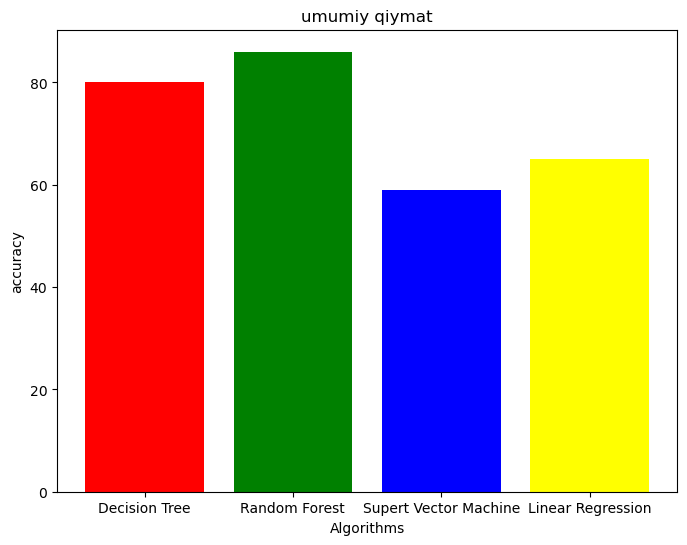

In [99]:
algorithm = ['Decision Tree','Random Forest','Supert Vector Machine','Linear Regression'] 
value = [80,86,59,65]
plt.figure(figsize=(8,6))
plt.bar(algorithm,value,color=['red','green','blue','yellow'])
plt.title('umumiy qiymat')
plt.xlabel('Algorithms')
plt.ylabel('accuracy')
plt.show()

# modelni saqlaymiz

In [ ]:
from joblib import dump

In [103]:
dump(RF_Reg,'Predict(car_mpg)')

['Predict(car_mpg)']